In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

ANALYTICS_DIR  = "sálvame/trials_3000_startupfix"
FULL_HP        = 176
TOP_N_ACTIONS  = 5  # number of actions shown in each action distribution chart
FIGURES_DIR    = "figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

matches = pd.read_csv(f"{ANALYTICS_DIR}/matches.csv")
rounds  = pd.read_csv(f"{ANALYTICS_DIR}/rounds.csv")
actions = pd.read_csv(
    f"{ANALYTICS_DIR}/actions.csv",
    dtype={"matchup": "category", "p1_name": "category", "p2_name": "category",
           "player": "category", "player_name": "category", "action": str,
           "episode": "int32", "round": "int8", "count": "int32"},
)

MATCHUPS = [
    "Curriculum_vs_CPU",
    "Rewards_vs_CPU",
    "Curriculum_vs_Rewards",
    "Rewards_vs_Curriculum",
]

print("Rows loaded:")
print(f"  matches : {len(matches):,}")
print(f"  rounds  : {len(rounds):,}")
print(f"  actions : {len(actions):,}")

Rows loaded:
  matches : 12,000
  rounds  : 27,648
  actions : 7,027,314


---
## 1 — Win Rate Summary

In [2]:
def pct(n, d):
    return 100 * n / d if d else 0.0

rows = []
for mu in MATCHUPS:
    p1_name, p2_name = mu.split("_vs_")
    for level, df, wcol in [
        ("match", matches[matches.matchup == mu], "match_winner"),
        ("round", rounds[rounds.matchup == mu],   "round_winner"),
    ]:
        p1   = (df[wcol] == "p1").sum()
        p2   = (df[wcol] == "p2").sum()
        draw = (df[wcol] == "draw").sum()
        tot  = len(df)
        rows.append({
            "matchup":    mu,
            "level":      level,
            "p1_name":    p1_name,
            "p2_name":    p2_name,
            "p1_wins":    p1,
            "p2_wins":    p2,
            "draws":      draw,
            "total":      tot,
            "p1_win_pct": round(pct(p1, tot), 1),
            "p2_win_pct": round(pct(p2, tot), 1),
            "draw_pct":   round(pct(draw, tot), 1),
        })

summary_df = pd.DataFrame(rows)
summary_df

,matchup,level,p1_name,p2_name,p1_wins,p2_wins,draws,total,p1_win_pct,p2_win_pct,draw_pct
0,Curriculum_vs_CPU,match,Curriculum,CPU,2656,329,15,3000,88.5,11.0,0.5
1,Curriculum_vs_CPU,round,Curriculum,CPU,5654,1294,26,6974,81.1,18.6,0.4
2,Rewards_vs_CPU,match,Rewards,CPU,2625,365,10,3000,87.5,12.2,0.3
3,Rewards_vs_CPU,round,Rewards,CPU,5605,1339,16,6960,80.5,19.2,0.2
4,Curriculum_vs_Rewards,match,Curriculum,Rewards,2849,147,4,3000,95.0,4.9,0.1
5,Curriculum_vs_Rewards,round,Curriculum,Rewards,5789,905,15,6709,86.3,13.5,0.2
6,Rewards_vs_Curriculum,match,Rewards,Curriculum,2652,343,5,3000,88.4,11.4,0.2
7,Rewards_vs_Curriculum,round,Rewards,Curriculum,5521,1466,18,7005,78.8,20.9,0.3


  Curriculum_vs_CPU
    Match winrate  — Curriculum: 61.7% (1852/3000)   CPU: 37.4% (1122/3000)   draw: 26
    Round winrate  — Curriculum: 56.2% (4174/7422)   CPU: 43.2% (3204/7422)   draw: 44

  Rewards_vs_CPU
    Match winrate  — Rewards: 63.1% (1894/3000)   CPU: 36.4% (1093/3000)   draw: 13
    Round winrate  — Rewards: 57.6% (4311/7480)   CPU: 42.1% (3151/7480)   draw: 18

  Curriculum_vs_Rewards
    Match winrate  — Curriculum: 94.2% (2827/3000)   Rewards: 5.6% (169/3000)   draw: 4
    Round winrate  — Curriculum: 84.6% (5747/6795)   Rewards: 15.1% (1027/6795)   draw: 21

  Rewards_vs_Curriculum
    Match winrate  — Rewards: 73.8% (2215/3000)   Curriculum: 26.0% (781/3000)   draw: 4
    Round winrate  — Rewards: 63.5% (4813/7578)   Curriculum: 36.4% (2756/7578)   draw: 9


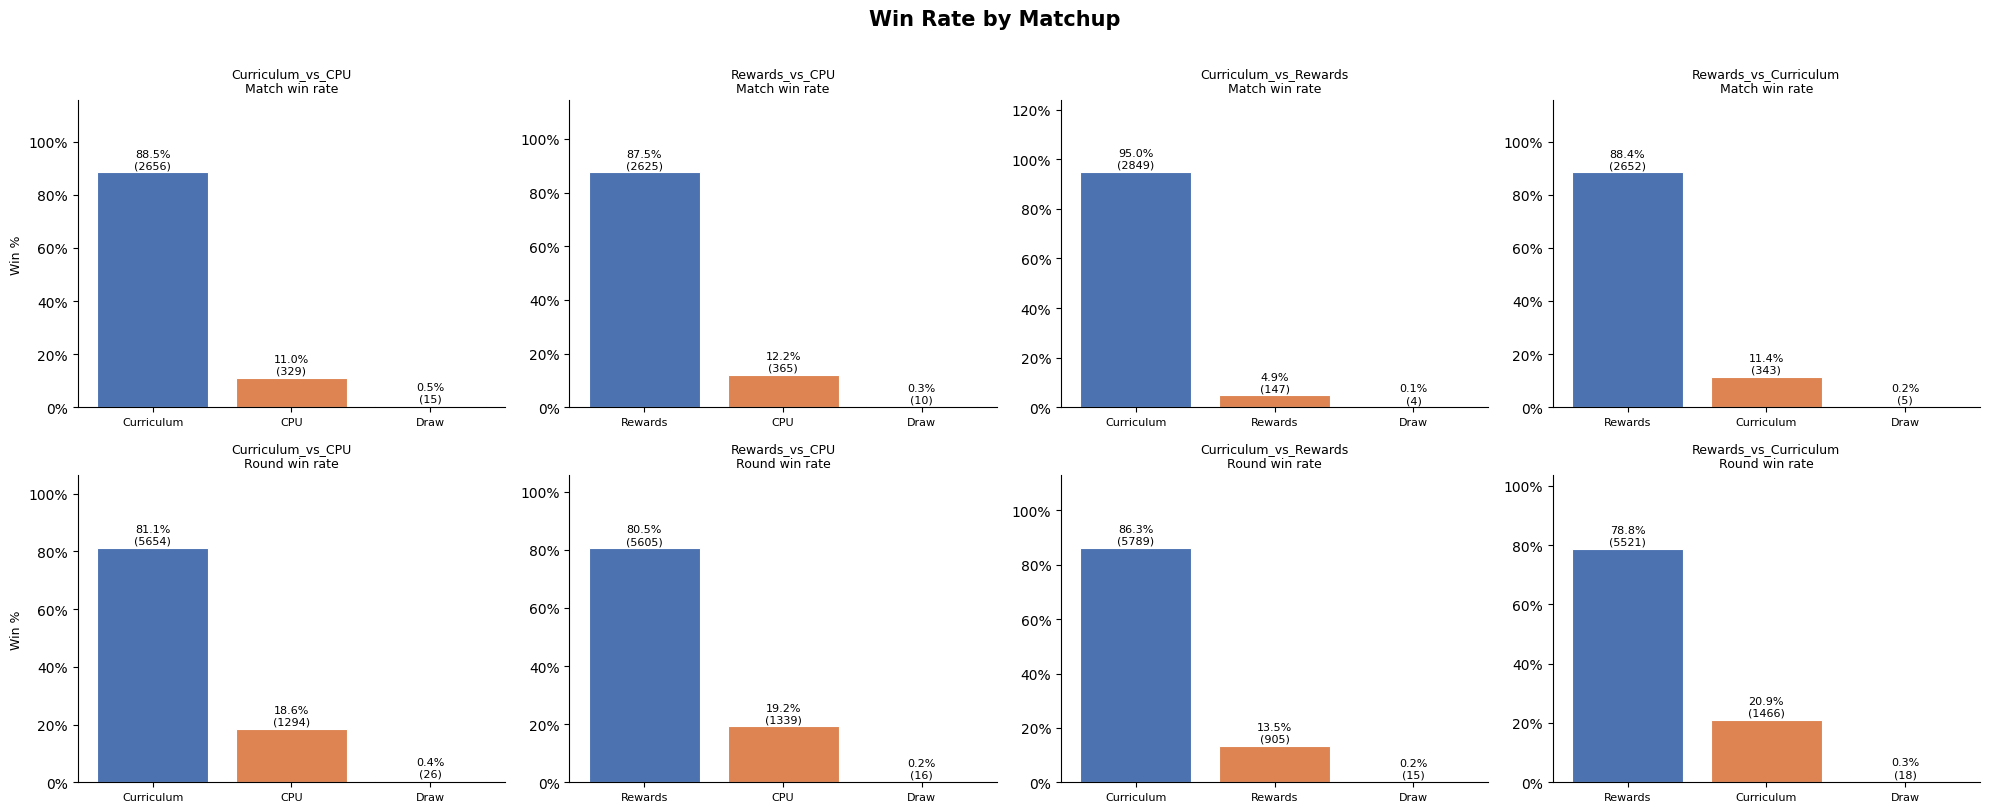

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=False)
fig.suptitle("Win Rate by Matchup", fontsize=15, fontweight="bold", y=1.01)

BAR_COLORS = ["#4C72B0", "#DD8452", "#8c8c8c"]

for col, mu in enumerate(MATCHUPS):
    for row, level in enumerate(["match", "round"]):
        ax   = axes[row][col]
        row_ = summary_df[(summary_df.matchup == mu) & (summary_df.level == level)].iloc[0]

        labels = [row_["p1_name"], row_["p2_name"], "Draw"]
        vals   = [row_["p1_win_pct"], row_["p2_win_pct"], row_["draw_pct"]]
        counts = [row_["p1_wins"],    row_["p2_wins"],    row_["draws"]]

        bars = ax.bar(labels, vals, color=BAR_COLORS, edgecolor="white", linewidth=0.8)
        for bar, cnt in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.8,
                    f"{bar.get_height():.1f}%\n({cnt})",
                    ha="center", va="bottom", fontsize=8)

        ax.set_ylim(0, max(vals) * 1.25 + 5)
        ax.set_ylabel("Win %" if col == 0 else "", fontsize=9)
        ax.set_title(f"{mu}\n{level.capitalize()} win rate", fontsize=9)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.tick_params(axis="x", labelsize=8)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/winrate_by_matchup.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2 — Action Distributions

In [4]:
BUTTONS = ['B', 'A', 'MODE', 'START', 'UP', 'DOWN', 'LEFT', 'RIGHT', 'C', 'Y', 'X', 'Z']

SF_COMBOS_BUTTONS = [
    [['DOWN'], ['DOWN', 'RIGHT'], ['RIGHT'], ['X']],  # Hadouken facing right
    [['RIGHT'], ['DOWN'], ['DOWN', 'RIGHT'], ['X']],  # Shoryuken facing right
    [['DOWN'], ['DOWN', 'LEFT'], ['LEFT'], ['A']],    # Tatsumaki facing right
    [['DOWN'], ['DOWN', 'LEFT'], ['LEFT'], ['X']],    # Hadouken facing left
    [['LEFT'], ['DOWN'], ['DOWN', 'LEFT'], ['X']],    # Shoryuken facing left
    [['DOWN'], ['DOWN', 'RIGHT'], ['RIGHT'], ['A']],  # Tatsumaki facing left
]

DIRECTIONS_BUTTONS = [
    [],                              # No direction (neutral)
    ['UP'], ['DOWN'],
    ['LEFT'], ['RIGHT'],
    ['UP', 'LEFT'],
    ['UP', 'RIGHT'],
    ['DOWN', 'LEFT'],  # crouching block
    ['DOWN', 'RIGHT'], # crouching block
]

ATTACKS_BUTTONS = [
    [],           # No attack (neutral)
    ['B'], ['A'], ['C'],  # Light / medium / strong punch (Genesis mapping)
    ['Y'], ['X'], ['Z'],  # Light / medium / strong kick
]

In [5]:
COMBO_NAMES = {
    0: "Hadouken",
    1: "Shoryuken",
    2: "Tatsumaki",
    3: "Hadouken",
    4: "Shoryuken",
    5: "Tatsumaki",
}

_combo_re = re.compile(r"\s*\[combo (\d+)\]$")

def label_action(s):
    m = _combo_re.search(s)
    if m:
        return COMBO_NAMES.get(int(m.group(1)), _combo_re.sub("", s))
    return s

actions["display_action"] = actions["action"].apply(label_action)

def top_actions(matchup, player_name, top_n=None):
    sl  = actions[(actions.matchup == matchup) & (actions.player_name == player_name)]
    agg = sl.groupby("display_action")["count"].sum().sort_values(ascending=False)
    agg = agg[~agg.index.str.contains("START")]
    return agg.head(top_n or TOP_N_ACTIONS)

def plot_action_dist(ax, matchup, player_name, color, top_n=None, figure_letter=None):
    data  = top_actions(matchup, player_name, top_n)
    total = data.sum()
    pcts  = 50 * data / total
    bars = ax.barh(range(len(pcts)), pcts.values, color=color, edgecolor="white", linewidth=0.5, height=0.4)
    ax.set_yticks(range(len(pcts)))
    ax.set_yticklabels(pcts.index, fontsize=14)
    ax.invert_yaxis()
    xlabel = f"({figure_letter}) % of all steps" if figure_letter else "% of all actions"
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_title(f"{player_name}  ({matchup})", fontsize=16, fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.spines[["top", "right"]].set_visible(False)
    for bar, pct_val in zip(bars, pcts.values):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                f"{pct_val:.1f}%", va="center", fontsize=12)
    ax.set_xlim(0, pcts.max() * 1.18)
    return ax

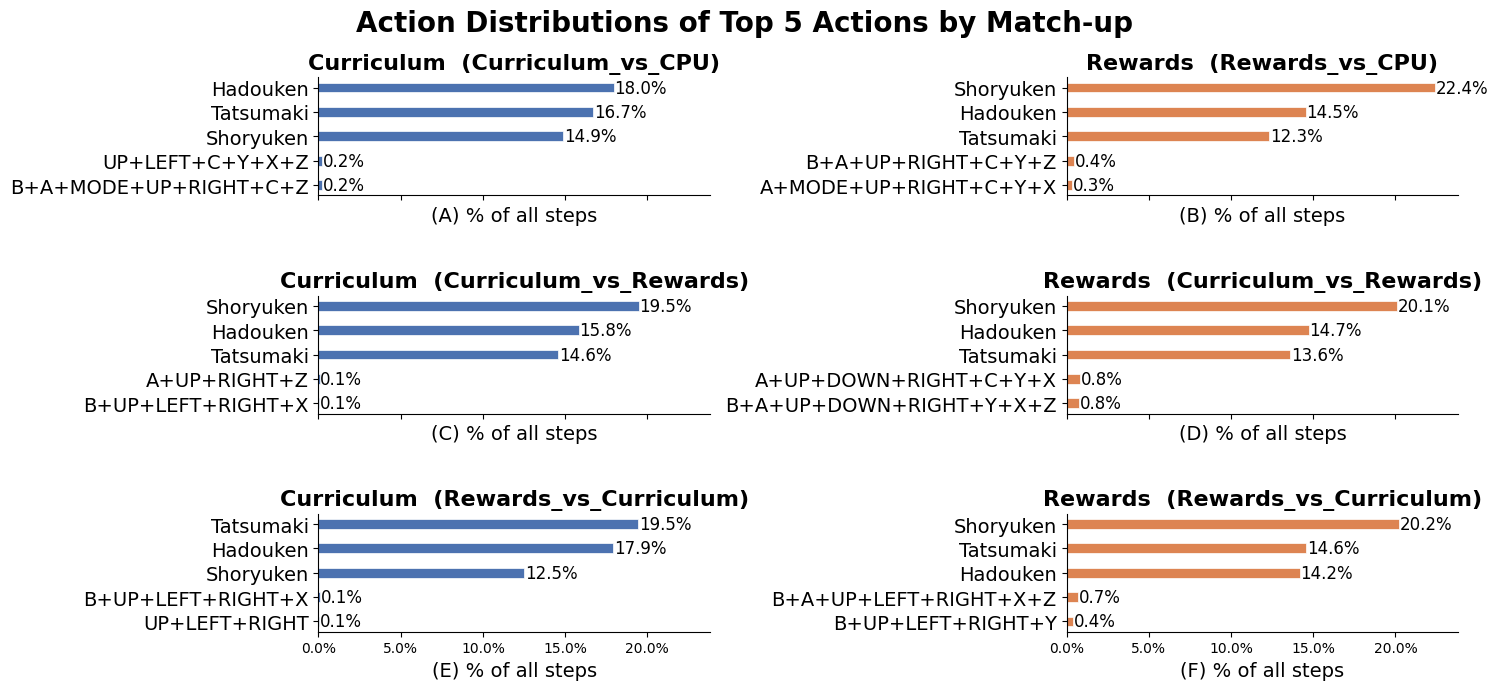

In [6]:
n_rows = TOP_N_ACTIONS
row_height = 0.5  # inches per bar
fig, axes = plt.subplots(3, 2, figsize=(15, n_rows * row_height * 2 + 2), sharex=True)

# fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle(f"Action Distributions of Top {TOP_N_ACTIONS} Actions by Match-up", fontsize=20, fontweight="bold")

configs = [
    ("Curriculum_vs_CPU",     "Curriculum", "#4C72B0", "A"),
    ("Rewards_vs_CPU",        "Rewards",    "#DD8452", "B"),
    ("Curriculum_vs_Rewards", "Curriculum", "#4C72B0", "C"),
    ("Curriculum_vs_Rewards", "Rewards", "#DD8452", "D"),
    ("Rewards_vs_Curriculum", "Curriculum", "#4C72B0", "E"),
    ("Rewards_vs_Curriculum", "Rewards",    "#DD8452", "F"),
]

for ax, (matchup, player, color, letter) in zip(axes.flat, configs):
    plot_action_dist(ax, matchup, player, color, figure_letter=letter)
    # ax.set_ylim(TOP_N_ACTIONS - 0.5, -0.5)

plt.tight_layout()
fig.subplots_adjust(hspace=0.85) 
fig.savefig(f"{FIGURES_DIR}/action_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3 — Final Health Difference Histograms

**Value = P1 (left) final HP − P2 (right) final HP.**  
Positive → left player survived with more health.  Negative → right player survived with more health.  
Max range: −176 (left KO'd, right at full HP) to +176 (right KO'd, left at full HP).

In [7]:
rounds.loc[rounds["p1_hp_final"] < 0, "p1_hp_final"] = 0
rounds.loc[rounds["p2_hp_final"] < 0, "p2_hp_final"] = 0

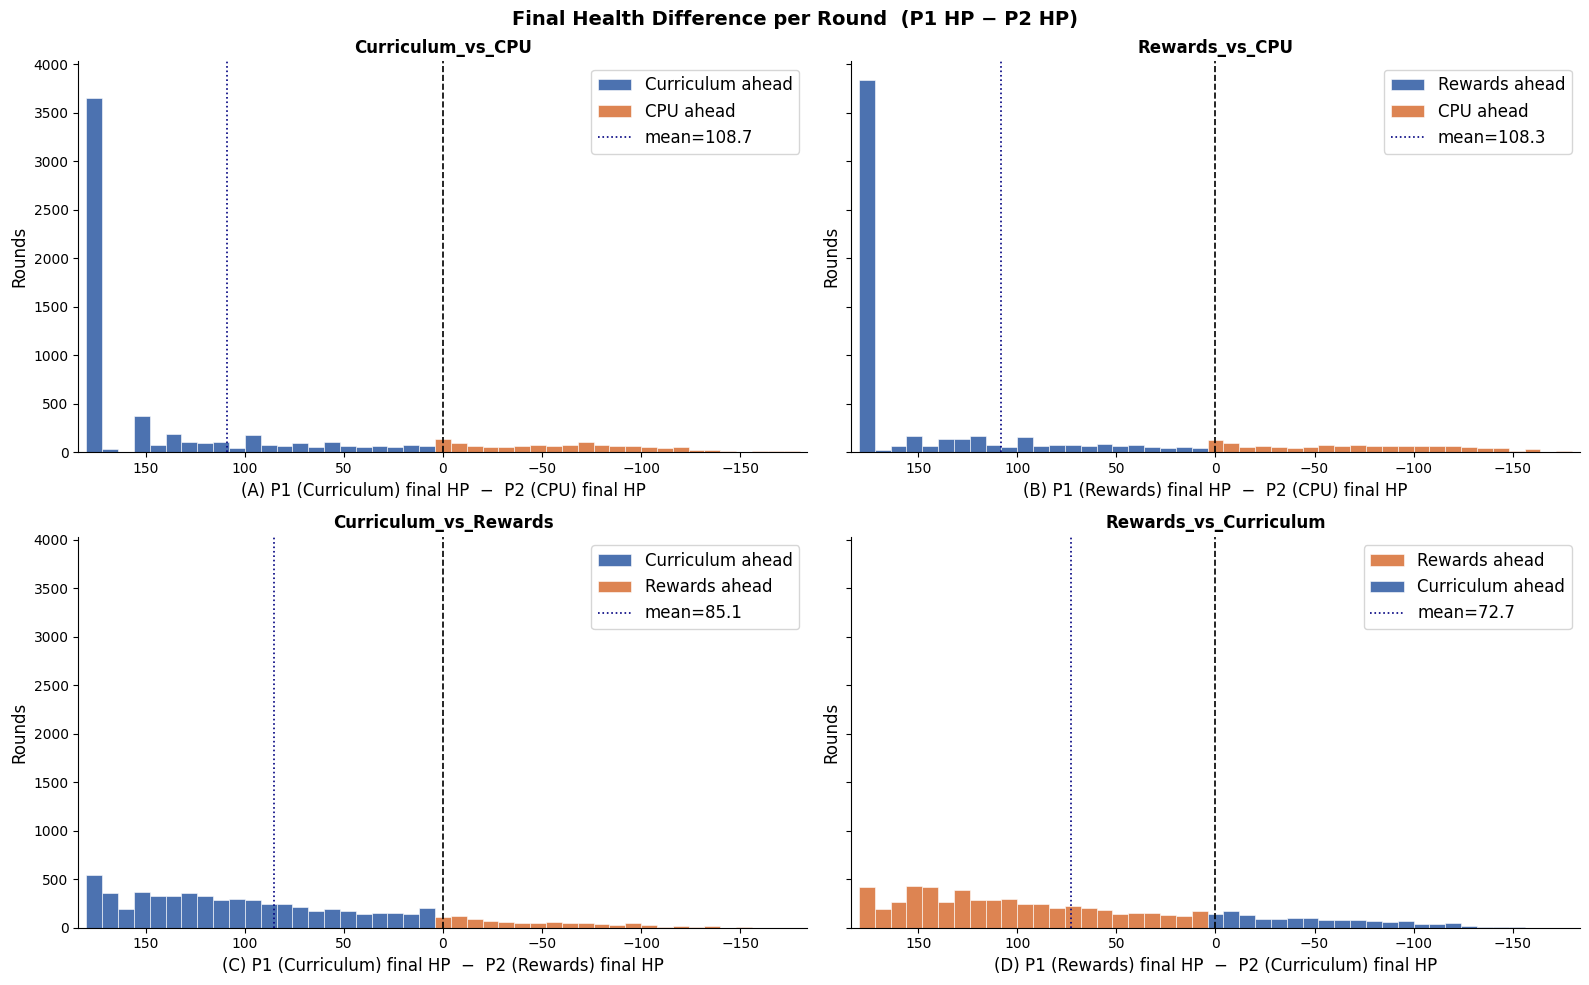

In [8]:
rounds["hp_diff"] = rounds["p1_hp_final"] - rounds["p2_hp_final"]

def plot_hp_diff(ax, matchup, color_left, color_right, figure_letter):
    p1_name, p2_name = matchup.split("_vs_")
    sl = rounds[rounds.matchup == matchup]["hp_diff"]

    bins = np.arange(-FULL_HP - 4, FULL_HP + 8, 8)   # 8-HP bins across full range

    pos = sl[sl > 0]
    neg = sl[sl < 0]
    if len(pos):
        ax.hist(pos, bins=bins, color=color_left,  edgecolor="white", linewidth=0.4,
                label=f"{p1_name} ahead")
    if len(neg):
        ax.hist(neg, bins=bins, color=color_right, edgecolor="white", linewidth=0.4,
                label=f"{p2_name} ahead")

    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
    ax.axvline(sl.mean(), color="navy", linewidth=1.2, linestyle=":",
               label=f"mean={sl.mean():.1f}")

    ax.set_xlabel(f"({figure_letter}) P1 ({p1_name}) final HP  −  P2 ({p2_name}) final HP", fontsize=12)
    ax.set_ylabel("Rounds", fontsize=12)
    ax.set_title(matchup, fontsize=12, fontweight="bold")
    ax.set_xlim(FULL_HP + 8, -FULL_HP - 8)
    ax.legend(fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
fig.suptitle("Final Health Difference per Round  (P1 HP − P2 HP)",
             fontsize=14, fontweight="bold")

configs = [
    ("Curriculum_vs_CPU",        "#4C72B0", "#DD8452"),
    ("Rewards_vs_CPU",           "#4C72B0", "#DD8452"),
    ("Curriculum_vs_Rewards",    "#4C72B0", "#DD8452"),
    ("Rewards_vs_Curriculum",    "#DD8452", "#4C72B0"),
]

figure_letters = ["A", "B", "C", "D"]
for i, (ax, (mu, cl, cr)) in enumerate(zip(axes.flat, configs)):
    plot_hp_diff(ax, mu, cl, cr, figure_letters[i])

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/hp_diff_histograms.png", dpi=150, bbox_inches="tight")
plt.show()